In [23]:
import importlib
importlib.reload(ct)

<module 'core_tools' from 'd:\\Amsterdam Uni\\BEE\\2026\\Coding\\core_tools.py'>

# 1. Setup & Data Loading
This section imports our statistical tools, our custom `core_tools` engine, and loads the cleaned dataset.

## March data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Import your custom engine
import core_tools as ct

# Load the cleaned data 
df_clean = pd.read_csv('data/2026_surveydata_cleaned_v1.csv')
print(f"Data loaded successfully! Total apiaries to analyze: {df_clean.shape[0]}")

Data loaded successfully! Total apiaries to analyze: 452


## April data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Import your custom engine
import core_tools as ct

# Load the cleaned data 
df_clean = pd.read_csv('../data/cleaned/2026_surveydata_cleaned_v2.csv')
print(f"Data loaded successfully! Total apiaries to analyze: {df_clean.shape[0]}")

Data loaded successfully! Total apiaries to analyze: 833


# 2. The Master Variable List
Add any new variables here in the future. The execution engine below will automatically generate the table, chart, and statistical test for every variable in this list.

In [16]:
# List format: ('column_name_in_csv', dictionary_from_core_tools)
variables_to_analyze = [
    ('imker_methode', ct.imker_methode_dict),
    ('winter_food', ct.winter_food_dict),
    ('varroa_treatment', ct.varroa_treatment_dict),
    ('aziatische_hoornaar', ct.aziatische_hoornaar_dict),
    ('deformed_wings',ct.deformed_wings_dict),
    ('varroa_observation',ct.varroa_observation_dict)
]

# 3. Execution Engine: Tables, Charts & Statistics
This loop processes everything at once. For each variable, it calculates the mortality rates, displays a clear bar chart, and runs a Chi-Square test to tell us if the differences are statistically significant (p < 0.05).

## April data

ANALYSIS: IMKER METHODE


,imker_methode,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Controlled,749,647,102,13.62
1,Natural,439,318,121,27.56
2,Regulier,2621,2020,601,22.93
3,Unknown and Mixed,1037,810,227,21.89


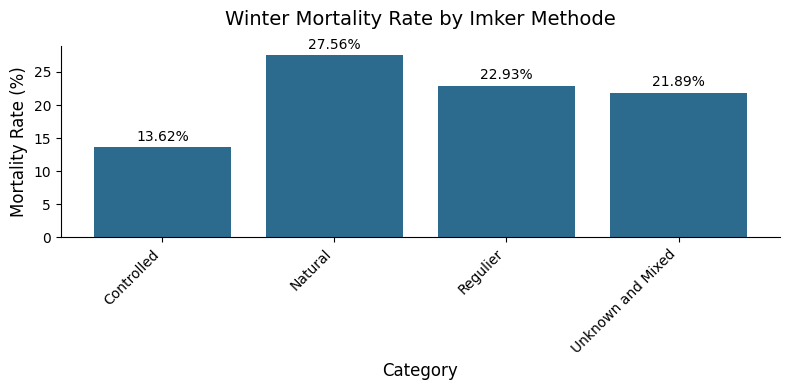


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 6 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0083

⭐ Significant Difference: Controlled vs Natural | P-Value: 0.00000
⭐ Significant Difference: Controlled vs Regulier | P-Value: 0.00000
⭐ Significant Difference: Controlled vs Unknown and Mixed | P-Value: 0.00001
   No Significant Difference: Natural vs Regulier | P-Value: 0.03988
   No Significant Difference: Natural vs Unknown and Mixed | P-Value: 0.02262
   No Significant Difference: Regulier vs Unknown and Mixed | P-Value: 0.52629



ANALYSIS: WINTER FOOD


,winter_food,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Sugar,1123,895,228,20.30
1,Mixed,3274,2636,638,19.49
2,Honey,445,262,183,41.12


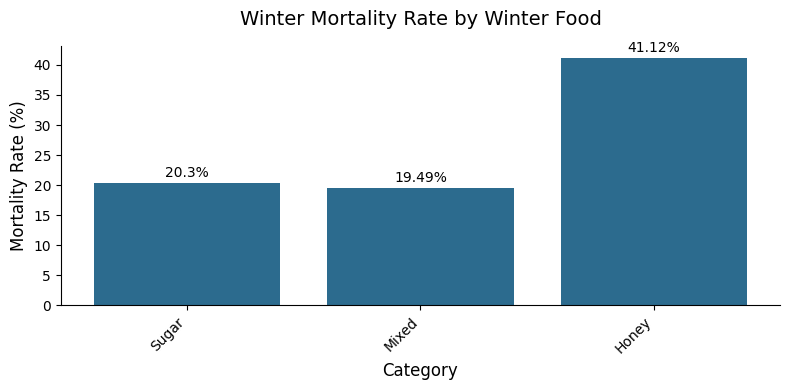


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 3 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0167

   No Significant Difference: Sugar vs Mixed | P-Value: 0.58248
⭐ Significant Difference: Sugar vs Honey | P-Value: 0.00000
⭐ Significant Difference: Mixed vs Honey | P-Value: 0.00000



ANALYSIS: VARROA TREATMENT


,varroa_treatment,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,3 gangenmenu full treatment,2407,1946,461,19.15
1,alternatieve behandeling,618,535,83,13.43
2,alleen in the winter,432,292,140,32.41
3,alleen in the zomer,623,446,177,28.41
4,Nee,766,576,190,24.80


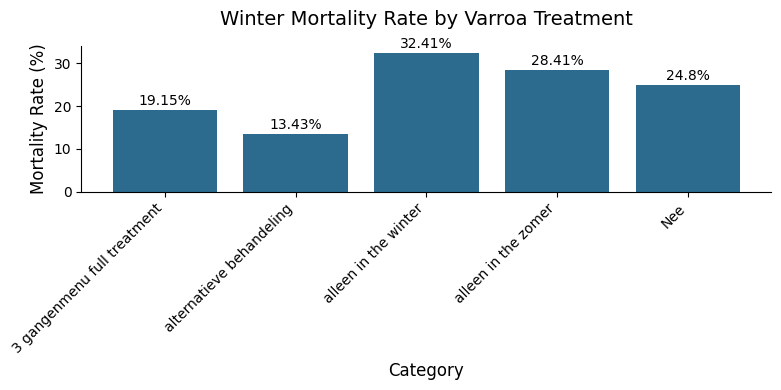


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 10 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0050

⭐ Significant Difference: 3 gangenmenu full treatment vs alternatieve behandeling | P-Value: 0.00117
⭐ Significant Difference: 3 gangenmenu full treatment vs alleen in the winter | P-Value: 0.00000
⭐ Significant Difference: 3 gangenmenu full treatment vs alleen in the zomer | P-Value: 0.00000
⭐ Significant Difference: 3 gangenmenu full treatment vs Nee | P-Value: 0.00089
⭐ Significant Difference: alternatieve behandeling vs alleen in the winter | P-Value: 0.00000
⭐ Significant Difference: alternatieve behandeling vs alleen in the zomer | P-Value: 0.00000
⭐ Significant Difference: alterna

In [14]:
from itertools import combinations # 引入用于生成两两组合的工具

for col, mapping_dict in variables_to_analyze:
    
    # --- 1. GENERATE SUMMARY TABLE ---
    summary_table = ct.winter_mortality_user_input_by_group(df_clean, col, mapping_dict=mapping_dict)
    
    print(f"============================================================")
    print(f"ANALYSIS: {col.replace('_', ' ').upper()}")
    print(f"============================================================")
    display(summary_table) 
    #summary_table.to_csv(f'outputs/appendix_table_single_variable_{col}.csv', index=False)
    
    # --- 2. GLOBAL CHI-SQUARE TEST ---
    grouped = df_clean.groupby(col)[['2025_winter_in', '2026_winter_uit']].sum()
    grouped['Died'] = grouped['2025_winter_in'] - grouped['2026_winter_uit']
    
    contingency_table = grouped[['2026_winter_uit', 'Died']]
    chi2_stat, global_p_value, dof, expected = chi2_contingency(contingency_table)
    
    # --- 3. DRAW THE CHART ---
    plt.figure(figsize=(8, 4))
    bars = plt.bar(summary_table[col].astype(str), summary_table['mortality_rate_%'], color='#2C6B8E')
    
    plt.title(f'Winter Mortality Rate by {col.replace("_", " ").title()}', fontsize=14, pad=15)
    plt.ylabel('Mortality Rate (%)', fontsize=12)
    plt.xlabel('Category', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', va='bottom', fontsize=10)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show() 
    
    # --- 4. PRINT STAT CONCLUSION & PAIRWISE TEST (English Version) ---
    print("\n--- 1. Global Chi-Square Test ---")
    print(f"Global P-Value: {global_p_value:.5f}")
    
    if global_p_value < 0.05:
        print("✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.\n")
        
        print("--- 2. Pairwise Comparisons (Post-hoc) ---")
        groups = contingency_table.index.tolist()
        pairs = list(combinations(groups, 2)) 
        
        bonferroni_alpha = 0.05 / len(pairs)
        print(f"💡 Statistical Rigor: Because we are making {len(pairs)} pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < {bonferroni_alpha:.4f}\n")
        
        for g1, g2 in pairs:
            table_2x2 = contingency_table.loc[[g1, g2]]
            stat, p_val, _, _ = chi2_contingency(table_2x2)
            
            label1 = mapping_dict.get(g1, g1) if mapping_dict else g1
            label2 = mapping_dict.get(g2, g2) if mapping_dict else g2
            
            if p_val < bonferroni_alpha:
                print(f"⭐ Significant Difference: {label1} vs {label2} | P-Value: {p_val:.5f}")
            else:
                print(f"   No Significant Difference: {label1} vs {label2} | P-Value: {p_val:.5f}")
                
    else:
        print("❌ NOT SIGNIFICANT: The differences in mortality rates between categories are likely due to random chance.")
        print("   (Pairwise comparisons are not necessary).")
    
    print("\n\n")

## April but with the second version

ANALYSIS: IMKER METHODE


,imker_methode,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Controlled,749,647,102,13.62
1,Natural,439,318,121,27.56
2,Regulier,2621,2020,601,22.93
3,Unknown and Mixed,1037,810,227,21.89


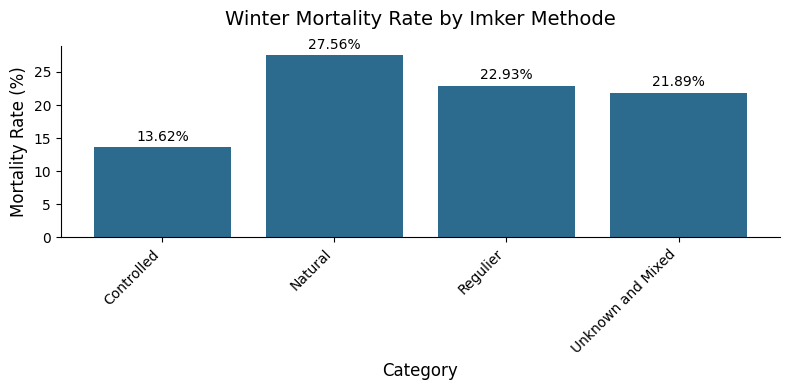


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 6 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0083

⭐ Significant Difference: Controlled vs Natural | P-Value: 0.00000
⭐ Significant Difference: Controlled vs Regulier | P-Value: 0.00000
⭐ Significant Difference: Controlled vs Unknown and Mixed | P-Value: 0.00001
   No Significant Difference: Natural vs Regulier | P-Value: 0.03988
   No Significant Difference: Natural vs Unknown and Mixed | P-Value: 0.02262
   No Significant Difference: Regulier vs Unknown and Mixed | P-Value: 0.52629



ANALYSIS: WINTER FOOD


,winter_food,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Sugar,1123,895,228,20.30
1,Mixed,3274,2636,638,19.49
2,Honey,446,263,183,41.03


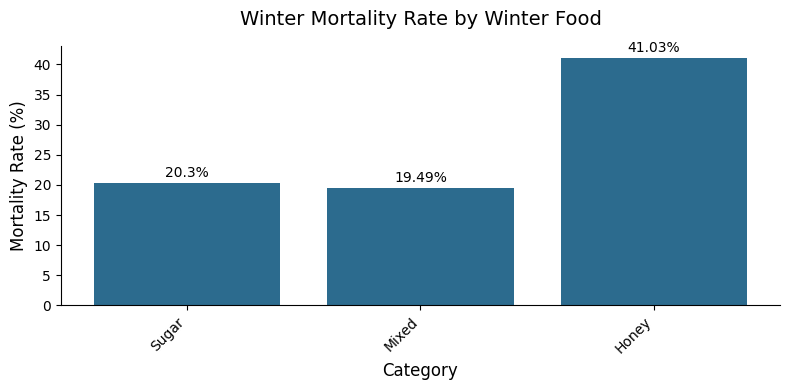


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 3 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0167

   No Significant Difference: Sugar vs Mixed | P-Value: 0.58248
⭐ Significant Difference: Sugar vs Honey | P-Value: 0.00000
⭐ Significant Difference: Mixed vs Honey | P-Value: 0.00000



ANALYSIS: VARROA TREATMENT


,varroa_treatment,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,3 gangenmenu full treatment,2407,1946,461,19.15
1,alternatieve behandeling,618,535,83,13.43
2,alleen in the winter,432,292,140,32.41
3,alleen in the zomer,623,446,177,28.41
4,Nee,767,577,190,24.77


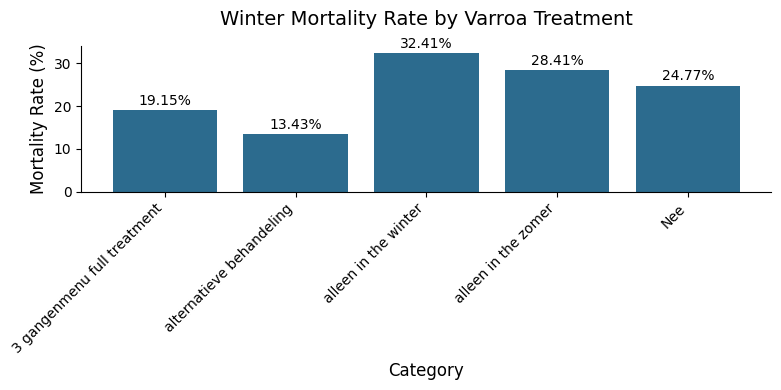


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 10 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0050

⭐ Significant Difference: 3 gangenmenu full treatment vs alternatieve behandeling | P-Value: 0.00117
⭐ Significant Difference: 3 gangenmenu full treatment vs alleen in the winter | P-Value: 0.00000
⭐ Significant Difference: 3 gangenmenu full treatment vs alleen in the zomer | P-Value: 0.00000
⭐ Significant Difference: 3 gangenmenu full treatment vs Nee | P-Value: 0.00095
⭐ Significant Difference: alternatieve behandeling vs alleen in the winter | P-Value: 0.00000
⭐ Significant Difference: alternatieve behandeling vs alleen in the zomer | P-Value: 0.00000
⭐ Significant Difference: alterna

,aziatische_hoornaar,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Nee,1708,1265,443,25.94
1,Weinig,980,778,202,20.61
2,Matig,1002,819,183,18.26
3,Veel,1100,894,206,18.73
4,Weet het niet,57,40,17,29.82


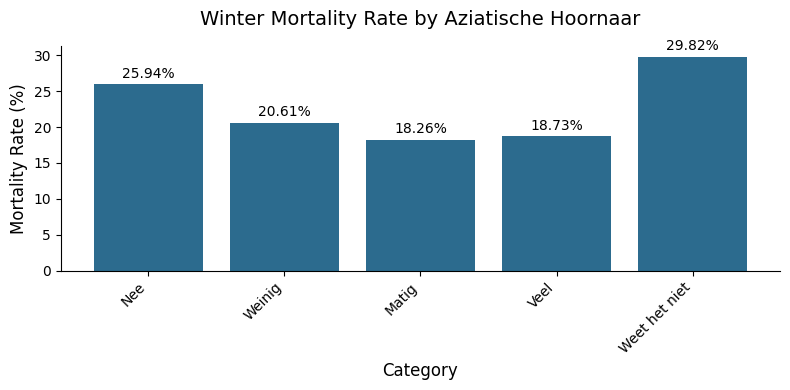


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00000
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 10 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0050

⭐ Significant Difference: Nee vs Weinig | P-Value: 0.00218
⭐ Significant Difference: Nee vs Matig | P-Value: 0.00001
⭐ Significant Difference: Nee vs Veel | P-Value: 0.00001
   No Significant Difference: Nee vs Weet het niet | P-Value: 0.61398
   No Significant Difference: Weinig vs Matig | P-Value: 0.20598
   No Significant Difference: Weinig vs Veel | P-Value: 0.30519
   No Significant Difference: Weinig vs Weet het niet | P-Value: 0.13631
   No Significant Difference: Matig vs Veel | P-Value: 0.82801
   No Significant Difference: Matig vs Weet het niet | P-Value: 0.04601
   No Signifi

,deformed_wings,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Nee,3552,2778,774,21.79
1,Weinig,755,592,163,21.59
2,Matig,176,137,39,22.16
3,Veel,2,2,0,0.00
4,Weet het niet,362,287,75,20.72


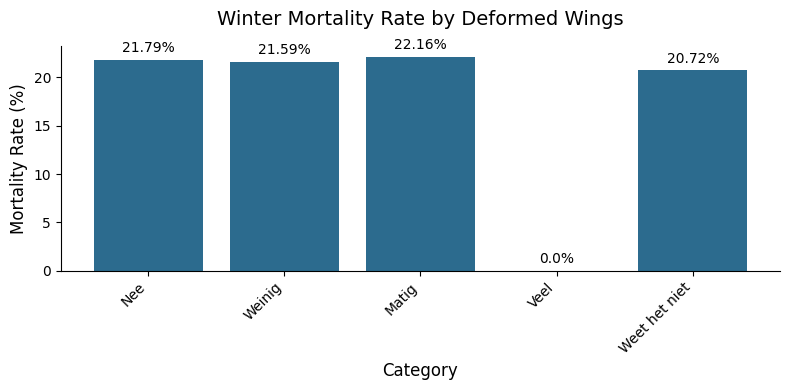


--- 1. Global Chi-Square Test ---
Global P-Value: 0.93795
❌ NOT SIGNIFICANT: The differences in mortality rates between categories are likely due to random chance.
   (Pairwise comparisons are not necessary).



ANALYSIS: VARROA OBSERVATION


,varroa_observation,2025_winter_in,2026_winter_uit,deaths,mortality_rate_%
0,Nee,301,207,94,31.23
1,Weinig,1626,1274,352,21.65
2,Matig,2172,1746,426,19.61
3,Veel,473,367,106,22.41
4,Weet het niet,275,202,73,26.55


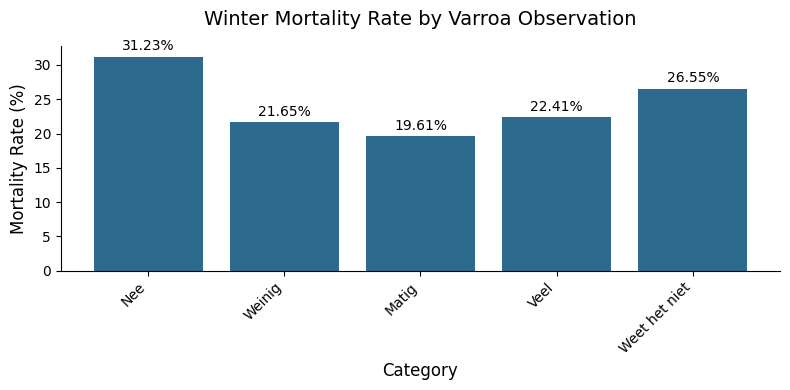


--- 1. Global Chi-Square Test ---
Global P-Value: 0.00004
✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.

--- 2. Pairwise Comparisons (Post-hoc) ---
💡 Statistical Rigor: Because we are making 10 pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < 0.0050

⭐ Significant Difference: Nee vs Weinig | P-Value: 0.00039
⭐ Significant Difference: Nee vs Matig | P-Value: 0.00001
   No Significant Difference: Nee vs Veel | P-Value: 0.00809
   No Significant Difference: Nee vs Weet het niet | P-Value: 0.25198
   No Significant Difference: Weinig vs Matig | P-Value: 0.13441
   No Significant Difference: Weinig vs Veel | P-Value: 0.77191
   No Significant Difference: Weinig vs Weet het niet | P-Value: 0.08462
   No Significant Difference: Matig vs Veel | P-Value: 0.18958
   No Significant Difference: Matig vs Weet het niet | P-Value: 0.00909
   No Sig

In [17]:
from itertools import combinations # 引入用于生成两两组合的工具

for col, mapping_dict in variables_to_analyze:
    
    # --- 1. GENERATE SUMMARY TABLE ---
    summary_table = ct.winter_mortality_user_input_by_group(df_clean, col, mapping_dict=mapping_dict)
    
    print(f"============================================================")
    print(f"ANALYSIS: {col.replace('_', ' ').upper()}")
    print(f"============================================================")
    display(summary_table) 
    #summary_table.to_csv(f'outputs/appendix_table_single_variable_{col}.csv', index=False)
    
    # --- 2. GLOBAL CHI-SQUARE TEST ---
    grouped = df_clean.groupby(col)[['2025_winter_in', '2026_winter_uit']].sum()
    grouped['Died'] = grouped['2025_winter_in'] - grouped['2026_winter_uit']
    
    contingency_table = grouped[['2026_winter_uit', 'Died']]
    chi2_stat, global_p_value, dof, expected = chi2_contingency(contingency_table)
    
    # --- 3. DRAW THE CHART ---
    plt.figure(figsize=(8, 4))
    bars = plt.bar(summary_table[col].astype(str), summary_table['mortality_rate_%'], color='#2C6B8E')
    
    plt.title(f'Winter Mortality Rate by {col.replace("_", " ").title()}', fontsize=14, pad=15)
    plt.ylabel('Mortality Rate (%)', fontsize=12)
    plt.xlabel('Category', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval}%', ha='center', va='bottom', fontsize=10)

    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show() 
    
    # --- 4. PRINT STAT CONCLUSION & PAIRWISE TEST (English Version) ---
    print("\n--- 1. Global Chi-Square Test ---")
    print(f"Global P-Value: {global_p_value:.5f}")
    
    if global_p_value < 0.05:
        print("✅ SIGNIFICANT: There is a statistically significant difference in mortality rates between the categories of this variable.\n")
        
        print("--- 2. Pairwise Comparisons (Post-hoc) ---")
        groups = contingency_table.index.tolist()
        pairs = list(combinations(groups, 2)) 
        
        bonferroni_alpha = 0.05 / len(pairs)
        print(f"💡 Statistical Rigor: Because we are making {len(pairs)} pairwise comparisons, we applied a Bonferroni correction to avoid false positives. The adjusted significance threshold is P < {bonferroni_alpha:.4f}\n")
        
        for g1, g2 in pairs:
            table_2x2 = contingency_table.loc[[g1, g2]]
            stat, p_val, _, _ = chi2_contingency(table_2x2)
            
            label1 = mapping_dict.get(g1, g1) if mapping_dict else g1
            label2 = mapping_dict.get(g2, g2) if mapping_dict else g2
            
            if p_val < bonferroni_alpha:
                print(f"⭐ Significant Difference: {label1} vs {label2} | P-Value: {p_val:.5f}")
            else:
                print(f"   No Significant Difference: {label1} vs {label2} | P-Value: {p_val:.5f}")
                
    else:
        print("❌ NOT SIGNIFICANT: The differences in mortality rates between categories are likely due to random chance.")
        print("   (Pairwise comparisons are not necessary).")
    
    print("\n\n")

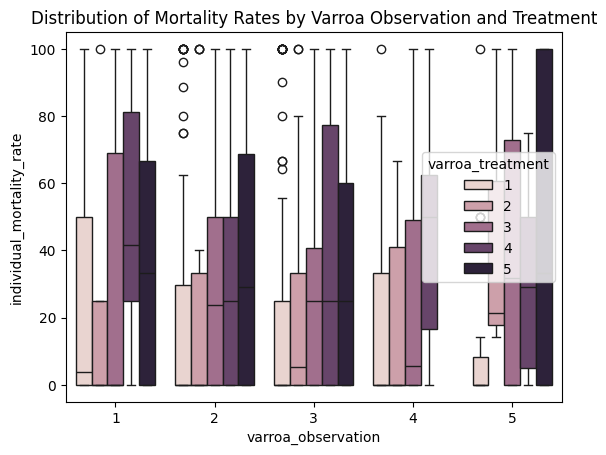

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate individual mortality rate for each row (beekeeper)
# Using np.where to prevent division by zero errors if '2025_winter_in' is 0
df_clean['individual_mortality_rate'] = np.where(
    df_clean['2025_winter_in'] > 0,
    ((df_clean['2025_winter_in'] - df_clean['2026_winter_uit']) / df_clean['2025_winter_in']) * 100,
    0
)

# Generate the grouped boxplot
sns.boxplot(
    data=df_clean, 
    x='varroa_observation', 
    y='individual_mortality_rate', 
    hue='varroa_treatment'
)
plt.title('Distribution of Mortality Rates by Varroa Observation and Treatment')
plt.show()

# 4. Deep Dives & Custom Requests
Use the cells below to answer specific, ad-hoc questions from your boss (e.g., "What is the mortality rate for Biodynamic beekeepers specifically in Utrecht?").